[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tommy-Burns/easy-eo/blob/main/examples/02_data_access/02_stac_search_and_load.ipynb)

# Searching and loading from STAC

Find real satellite scenes by place, time and cloudiness, and read just the part you need - straight over HTTP, with no full-scene downloads.

- **Data:** Sentinel-2 L2A from Microsoft Planetary Computer
- **Network: required.** This notebook talks to a live catalog, so its outputs are not stored in the repository — run it yourself.
- **Requires:** `pip install "easy-eo[stac]"`

In [ ]:
# Running in Colab? Install Easy-EO. Does nothing anywhere else.
import sys

if "google.colab" in sys.modules:
    %pip install -q "easy-eo[stac]"


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

# Keeps the figures stored in this notebook small; raise it for print-quality output.
plt.rcParams["figure.dpi"] = 80

In [2]:
import eeo

eeo.show_versions()

Easy-EO version information
easy-eo            : 0.1.0b1
python             : 3.10.19
OS                 : Linux 7.0.0-28-generic
rasterio           : 1.4.3
GDAL               : 3.6.2
numpy              : 1.26.4
geopandas          : 1.1.1
matplotlib         : 3.10.6
xarray             : 2025.4.0
rioxarray          : 0.19.0
dask               : not installed
pystac-client      : 0.9.0
planetary-computer : 1.0.0


## Searching

`stac_search` queries a STAC catalog and returns matching scenes. It fetches **metadata only** - no pixels are read and nothing is downloaded.

The bounding box is always in **WGS 84 lon/lat degrees** (`minx, miny, maxx, maxy`), whatever CRS the imagery itself uses.

In [3]:
# Passau, Germany - the area the bundled sample was cut from
bbox = (13.37, 48.22, 13.47, 48.28)

results = eeo.stac_search(
    "sentinel-2-l2a",
    bbox=bbox,
    datetime="2023-06-01/2023-09-30",
    cloud_cover=10,
    limit=10,
)

print(f"{len(results)} scenes")
print("catalog:", results.catalog)
print("bbox   :", results.bbox)

10 scenes
catalog: https://planetarycomputer.microsoft.com/api/stac/v1
bbox   : (13.37, 48.22, 13.47, 48.28)


Results come back **oldest first**, each carrying its acquisition timestamp - the ordering a time series needs.

In [4]:
for item in results:
    print(f"{item.timestamp:%Y-%m-%d}  cloud {item.cloud_cover:5.2f}%  {item.id}")

2023-09-05  cloud  7.70%  S2B_MSIL2A_20230905T100559_R022_T33UUP_20241102T142635
2023-09-07  cloud  0.00%  S2A_MSIL2A_20230907T100031_R122_T33UUP_20241025T114023
2023-09-07  cloud  0.00%  S2A_MSIL2A_20230907T100031_R122_T33UUP_20230907T213241
2023-09-10  cloud  0.14%  S2A_MSIL2A_20230910T100601_R022_T33UUP_20230910T182156
2023-09-15  cloud  5.09%  S2B_MSIL2A_20230915T100639_R022_T33UUP_20230915T180829
2023-09-17  cloud  5.22%  S2A_MSIL2A_20230917T100031_R122_T33UUP_20241101T051059
2023-09-17  cloud  5.27%  S2A_MSIL2A_20230917T100031_R122_T33UUP_20230917T171411
2023-09-20  cloud  0.18%  S2A_MSIL2A_20230920T100711_R022_T33UUP_20241101T113758
2023-09-20  cloud  0.18%  S2A_MSIL2A_20230920T100711_R022_T33UUP_20230920T162327
2023-09-27  cloud  2.78%  S2A_MSIL2A_20230927T100031_R122_T33UUP_20230927T161804


In [5]:
print("timestamps:", results.timestamps[:3])
print("collections:", results.collections)
print("\nslicing works:", len(results[:3]), "of", len(results))
print("newest scene:", results[-1].id)

timestamps: [datetime.datetime(2023, 9, 5, 10, 5, 59, 24000, tzinfo=tzutc()), datetime.datetime(2023, 9, 7, 10, 0, 31, 24000, tzinfo=tzutc()), datetime.datetime(2023, 9, 7, 10, 0, 31, 24000, tzinfo=tzutc())]
collections: ['sentinel-2-l2a']

slicing works: 3 of 10
newest scene: S2A_MSIL2A_20230927T100031_R122_T33UUP_20230927T161804


### The filters

- `datetime` - an interval `"2023-06-01/2023-09-30"`, a single instant, or a `(start, end)` pair. `".."` leaves one end open. A bare closing date is **inclusive**: the catalog expands it to the end of that day.
- `cloud_cover` - maximum percent cloud, applied by the catalog against each scene's own `eo:cloud_cover` value.
- `limit` - maximum number of items returned.
- `intersects` - a shape instead of a rectangle: a GeoDataFrame, a shapely geometry, GeoJSON, or a path to any vector file. Cannot be combined with `bbox`.

Two catalog behaviours are worth knowing rather than being surprised by: the cloud filter is applied to the catalog's own indexed value, so a scene can come back slightly above your threshold; and catalogs return **reprocessed duplicates** of  the same acquisition, which is why you may see one date twice.

In [6]:
from collections import Counter

dates = Counter(item.timestamp.date() for item in results)
for date, count in sorted(dates.items()):
    marker = "  <- duplicate acquisition" if count > 1 else ""
    print(f"{date}  x{count}{marker}")

2023-09-05  x1
2023-09-07  x2  <- duplicate acquisition
2023-09-10  x1
2023-09-15  x1
2023-09-17  x2  <- duplicate acquisition
2023-09-20  x2  <- duplicate acquisition
2023-09-27  x1


### Searching with a shape

In [7]:
from eeo.datasets import load_sample_dataset

sd = load_sample_dataset()

shaped = eeo.stac_search(
    "sentinel-2-l2a",
    intersects=str(sd.boundary.path),
    datetime="2023-09-01/2023-09-30",
    cloud_cover=20,
    limit=5,
)
print(f"{len(shaped)} scenes intersecting the sample ROI")

5 scenes intersecting the sample ROI


## Inspecting an item

Each result wraps the underlying `pystac.Item` (still reachable at `.item`) with the properties you actually want.

In [8]:
item = results[-1]

print("id         :", item.id)
print("collection :", item.collection)
print("timestamp  :", item.timestamp)
print("cloud      :", item.cloud_cover)
print("bbox       :", item.bbox)
print("\nassets:", ", ".join(sorted(a for a in item.asset_names if a.startswith("B"))))

id         : S2A_MSIL2A_20230927T100031_R122_T33UUP_20230927T161804
collection : sentinel-2-l2a
timestamp  : 2023-09-27 10:00:31.024000+00:00
cloud      : 2.782148
bbox       : (13.1043517, 47.74717905, 13.7964017, 48.74648044)

assets: B01, B02, B03, B04, B05, B06, B07, B08, B09, B11, B12, B8A


## Loading pixels

`load()` reads the assets you name into a single `EEORasterDataset`.

Crucially, it **crops to the search area of interest by default**. A Sentinel-2 tile is 110 km across; your AOI is usually a few kilometres. Items remember the search bbox, so the crop happens without you repeating it, and only the overlapping COG tiles travel over the network.

In [9]:
scene = item.load(["B02", "B03", "B04", "B08"])

scene.describe()

EEORasterDataset
  source      : <in-memory>
  driver      : GTiff
  bands       : 4
  band names  : 1: B02, 2: B03, 3: B04, 4: B08
  size        : 683 × 757  (height × width)
  dtype       : uint16
  crs         : EPSG:32633 — WGS 84 / UTM zone 33N
  pixel size  : 10 × 10  (CRS units)
  extent      : 378920, 5341880, 386490, 5348710  (minx, miny, maxx, maxy)
  nodata      : 0.0
  timestamp   : 2023-09-27T10:00:31.024000+00:00
  attrs       : stac_item=S2A_MSIL2A_20230927T100031_R122_T33UUP_20230927T161804, stac_collection=sentinel-2-l2a, stac_assets=['B02', 'B03', 'B04', 'B08']


Band names come from the asset keys, and the item's provenance travels with the dataset.

In [10]:
print("band names:", scene.band_names)
print("timestamp :", scene.timestamp)
print("\nattrs:")
for key, value in scene.attrs.items():
    print(f"  {key}: {value}")

band names: ['B02', 'B03', 'B04', 'B08']
timestamp : 2023-09-27 10:00:31.024000+00:00

attrs:
  stac_item: S2A_MSIL2A_20230927T100031_R122_T33UUP_20230927T161804
  stac_collection: sentinel-2-l2a
  stac_assets: ['B02', 'B03', 'B04', 'B08']


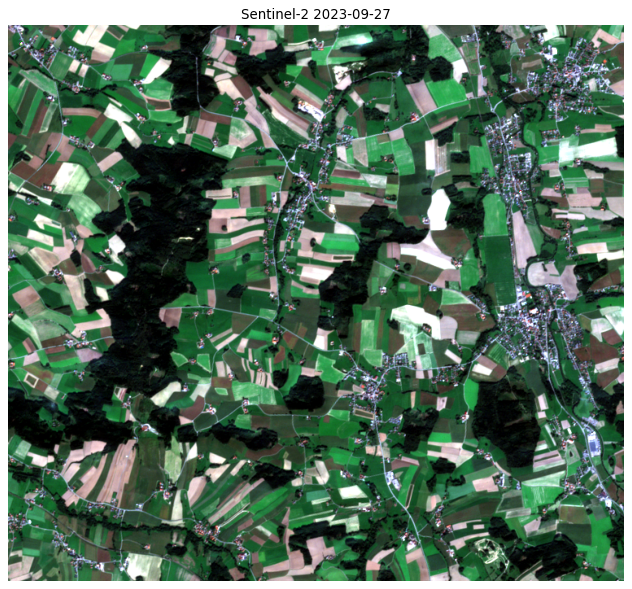

In [11]:
scene.plot_composite(["B04", "B03", "B02"], pmin=2, pmax=98,
                     title=f"Sentinel-2 {item.timestamp:%Y-%m-%d}")

### Controlling the crop

- `bbox=` overrides the search AOI for this load.
- `bbox=None, crop=False` reads the **whole tile** - which is a much larger transfer, so ask for it deliberately.

The first asset defines the output grid; the rest are read onto it. Bands that already share that grid are read exactly, with no resampling; coarser bands (Sentinel-2's 20 m SWIR, for instance) or bands in a different CRS are warped onto it.

In [12]:
smaller = item.load(["B04", "B08"], bbox=(13.40, 48.24, 13.43, 48.26))
print("default AOI :", scene.get_shape())
print("smaller bbox:", smaller.get_shape())

default AOI : (683, 757)
smaller bbox: (228, 228)


In [13]:
# a 10 m band and a 20 m band, returned on one grid
mixed = item.load(["B08", "B11"])
print(mixed.get_shape(), mixed.band_names, "- B11 warped onto B08's 10 m grid")

(683, 757) ['B08', 'B11'] - B11 warped onto B08's 10 m grid


## Straight into analysis

The loaded dataset is an ordinary `EEORasterDataset`, so every operation applies.

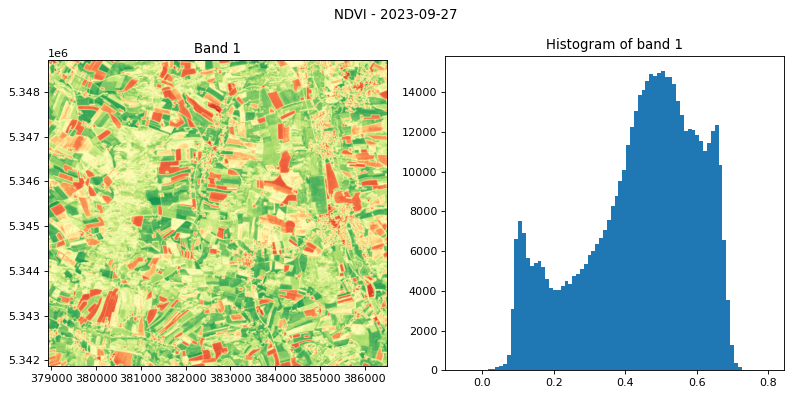

In [14]:
ndvi = scene.ndvi(red="B04", nir="B08")
ndvi.plot_raster_with_histogram(cmap="RdYlGn", bins=80,
                                title=f"NDVI - {item.timestamp:%Y-%m-%d}")

The whole workflow, start to finish:

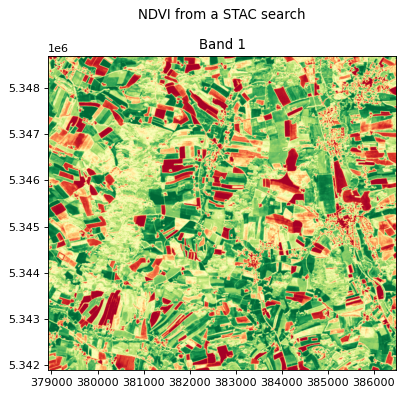

In [15]:
(
    eeo.stac_search("sentinel-2-l2a", bbox=bbox, datetime="2023-09-01/2023-09-30",
                    cloud_cover=10, limit=1)[-1]
    .load(["B04", "B08"])
    .ndvi(red="B04", nir="B08")
    .plot_raster(cmap="RdYlGn", title="NDVI from a STAC search")
)

## Other catalogs and collections

`stac_search` defaults to Microsoft Planetary Computer and signs its asset URLs automatically. Point `catalog=` at any STAC API; `sign=False` disables signing for catalogs that do not need it.

```python
results = eeo.stac_search(
    "sentinel-2-l2a",
    bbox=bbox,
    catalog="https://earth-search.aws.element84.com/v1",
    sign=False,
)
```

Landsat works the same way - only the collection id and asset names change (Landsat's NIR is `nir08`, its red is `red`):

```python
landsat = eeo.stac_search("landsat-c2-l2", bbox=bbox, datetime="2023-06-01/2023-09-30",
                          cloud_cover=10, limit=5)
scene = landsat[-1].load(["red", "nir08"])
ndvi = scene.ndvi(red="red", nir="nir08")
```

In [16]:
for ds in (scene, smaller, mixed, ndvi):
    ds.close()
print("closed")

closed


## Next

- **[../03_real_world/01_flood_mapping_ndwi](../03_real_world/01_flood_mapping_ndwi.ipynb)** - STAC applied to a real flood
- **[../03_real_world/03_urban_footprint_land_cover](../03_real_world/03_urban_footprint_land_cover.ipynb)** - SWIR-based indices on a real city